In [2]:
import pandas as pd

# Load datasets
price = pd.read_csv("../data/forex_price_data.csv")
mc = pd.read_csv("../data/mc_scenarios.csv")
trade = pd.read_csv("../data/trade_log.csv")

print("Forex Price Data")
display(price.head())

print("Monte Carlo Data")
display(mc.head())

print("Trade Log")
display(trade.head())

Forex Price Data


,DateTime,PairID,PairName,Open,High,Low,Close,Volume,Spread
0,2023-01-01 00:00:00,1,EUR/USD,1.08103,1.08103,1.08019,1.08054,2651,0.9
1,2023-01-01 01:00:00,1,EUR/USD,1.08010,1.08043,1.07974,1.08028,2292,1.0
2,2023-01-01 02:00:00,1,EUR/USD,1.08036,1.08158,1.07961,1.08054,1796,1.2
3,2023-01-01 03:00:00,1,EUR/USD,1.08068,1.08126,1.07973,1.08088,4019,1.4
4,2023-01-01 04:00:00,1,EUR/USD,1.08042,1.08042,1.07967,1.08030,2207,1.6


Monte Carlo Data


,ScenarioID,ParallelShift,VolShock,CorrShock,EURUSD_PnL,USDJPY_PnL,GBPUSD_PnL,PortfolioPnL
0,1,0.007477,0.047435,-0.005085,-47135.91,-12006.44,-16290.94,-75433.29
1,2,0.009984,-0.015458,-0.022252,-67806.11,-23561.05,-19792.70,-111159.86
2,3,0.017714,0.024560,0.021290,-105268.35,-37015.49,-30672.66,-172956.50
3,4,-0.003975,-0.015789,-0.028162,31602.99,2908.07,4799.50,39310.56
4,5,0.020120,0.006809,0.003554,-118486.89,-46873.73,-37796.98,-203157.60


Trade Log


,TradeID,PairName,StrategyName,SignalType,Direction,EntryPrice,ExitPrice,EntryDateTime,ExitDateTime,PositionSize,PnL,PnL_Pips,HoldingDays,Commission,IsOpen
0,1,USD/JPY,MACD_Trend,BUY,LONG,154.16999,154.17229,2024-07-15,2024-07-17 23:45:36.000000000,100000,2300.0,23.0,2.99,7.0,False
1,2,USD/INR,MA_Cross,STRONG_SELL,SHORT,83.90144,83.90070,2024-02-08,2024-02-10 11:45:36.000000000,100000,740.0,7.4,2.49,7.0,False
2,3,USD/JPY,RL_PPO,BUY,LONG,150.56125,150.56093,2024-06-26,2024-06-28 10:19:12.000000000,100000,-320.0,-3.2,2.43,7.0,False
3,4,GBP/USD,ML_RF,SELL,SHORT,1.23636,1.23434,2024-03-26,2024-03-28 14:24:00.000000000,100000,202.0,20.2,2.60,7.0,False
4,5,AUD/USD,RL_PPO,BUY,LONG,0.66810,0.66700,2024-06-05,2024-06-06 11:02:24.000000000,100000,-110.0,-11.0,1.46,7.0,False


In [3]:
print("========== TRADE LOG ==========")

print(trade.info())

print()

print(trade.describe())

print()

print("Missing Values")
print(trade.isnull().sum())

print()

print("Strategies")
print(trade["StrategyName"].unique())

print()

print("Signal Types")
print(trade["SignalType"].unique())

========== TRADE LOG ==========
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TradeID        150 non-null    int64  
 1   PairName       150 non-null    str    
 2   StrategyName   150 non-null    str    
 3   SignalType     150 non-null    str    
 4   Direction      150 non-null    str    
 5   EntryPrice     150 non-null    float64
 6   ExitPrice      150 non-null    float64
 7   EntryDateTime  150 non-null    str    
 8   ExitDateTime   150 non-null    str    
 9   PositionSize   150 non-null    int64  
 10  PnL            150 non-null    float64
 11  PnL_Pips       150 non-null    float64
 12  HoldingDays    150 non-null    float64
 13  Commission     150 non-null    float64
 14  IsOpen         150 non-null    bool   
dtypes: bool(1), float64(6), int64(2), str(6)
memory usage: 16.7 KB
None

          TradeID  EntryPrice   ExitPrice  PositionS

In [4]:
print("========== MONTE CARLO ==========")

print(mc.info())

print()

print(mc.describe())

print()

print("Missing Values")
print(mc.isnull().sum())

========== MONTE CARLO ==========
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ScenarioID     1000 non-null   int64  
 1   ParallelShift  1000 non-null   float64
 2   VolShock       1000 non-null   float64
 3   CorrShock      1000 non-null   float64
 4   EURUSD_PnL     1000 non-null   float64
 5   USDJPY_PnL     1000 non-null   float64
 6   GBPUSD_PnL     1000 non-null   float64
 7   PortfolioPnL   1000 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 62.6 KB
None

        ScenarioID  ParallelShift     VolShock    CorrShock     EURUSD_PnL  \
count  1000.000000    1000.000000  1000.000000  1000.000000    1000.000000   
mean    500.500000      -0.000256     0.001550    -0.000346    3832.546610   
std     288.819436       0.009875     0.049927     0.019751   64415.250771   
min       1.000000      -0.034258    -0.171268    -0.069338 -16

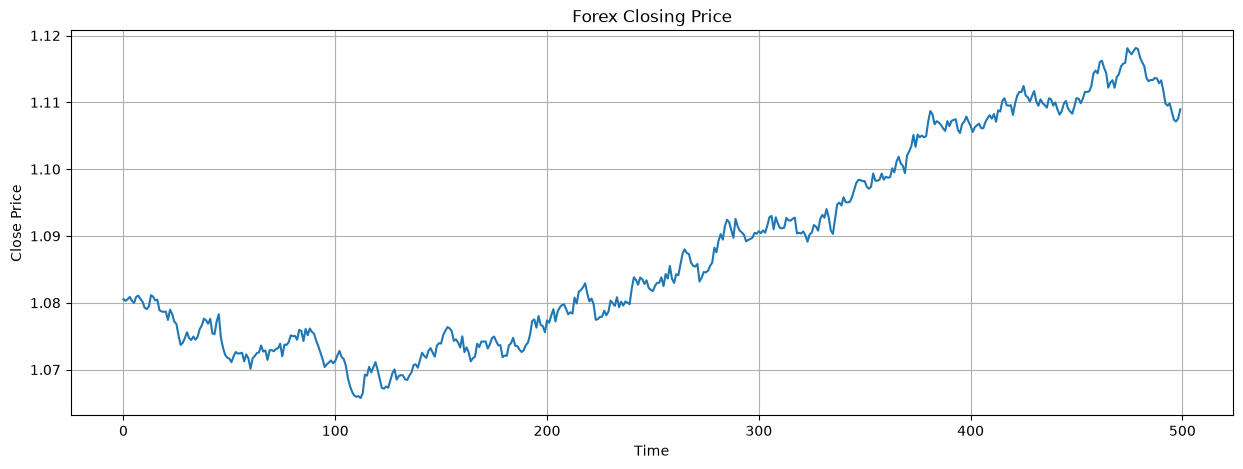

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(price["Close"])

plt.title("Forex Closing Price")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.grid(True)

plt.show()

